In [2]:
from google.colab import files
uploaded = files.upload()


Saving acti_autotara_dev_structured.csv to acti_autotara_dev_structured.csv
Saving acti_autotara_structured.csv to acti_autotara_structured.csv


In [3]:
import pandas as pd

df_train = pd.read_csv("acti_autotara_structured.csv")
df_dev   = pd.read_csv("acti_autotara_dev_structured.csv")

df_train.head(), df_dev.head()


(   scenario_id      asset      attack_type targeted_property impact_rating  \
 0            0        ECU    impact_attack      availability           low   
 1            1    Megamos  targeted_attack         integrity           low   
 2            2      Tesla   unknown_attack      availability          high   
 3            3    UNKNOWN   unknown_attack      availability          high   
 4            4  diagnotic     manipulation      availability          high   
 
                                        combined_text  
 0  ECU impact_attack availability During brute fo...  
 1  Megamos targeted_attack integrity Exploitation...  
 2  Tesla unknown_attack availability This kind of...  
 3  UNKNOWN unknown_attack availability Theft aler...  
 4  diagnotic manipulation availability Bleeding t...  ,
    scenario_id                                           sentence      asset  \
 0            0  US safety advocates argue that Hyundai and Kia...    UNKNOWN   
 1            1  Vgate iC

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    stop_words="english"
)

X_train = vectorizer.fit_transform(df_train["combined_text"])
X_test  = vectorizer.transform(df_dev["combined_text"])

y_train = df_train["impact_rating"]
y_test  = df_dev["impact_rating"]

X_train.shape, X_test.shape


((2426, 5645), (606, 5645))

In [7]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier


def evaluate_models_acti(df: pd.DataFrame, random_state: int = 21):
    """
    ACTI version of evaluate_models():
    - uses TF-IDF on combined_text
    - returns per-model metrics dict with acc/prec/rec/f1 and tp/tn/fp/fn
    """
    df = df.dropna(subset=["combined_text", "impact_rating"]).copy()

    X_text = df["combined_text"].astype(str)
    y = df["impact_rating"].astype(str)

    X_train_text, X_test_text, y_train, y_test = train_test_split(
        X_text, y, test_size=0.2, random_state=random_state, stratify=y
    )

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        stop_words="english"
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test  = vectorizer.transform(X_test_text)

    models = {
        "knn": KNeighborsClassifier(n_neighbors=5),
        "naive_bayes": MultinomialNB(alpha=1.0),
        "random_forest": RandomForestClassifier(
            n_estimators=200, random_state=random_state, class_weight="balanced"
        ),
    }

    labels = sorted(y.unique())  # consistent confusion-matrix ordering

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

        acc = accuracy_score(y_test, pred)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, pred, average="weighted", zero_division=0
        )

        cm = confusion_matrix(y_test, pred, labels=labels)

        # Multi-class totals (same idea as your teammate’s synthetic code)
        total = cm.sum()
        diag = np.diag(cm)
        row_sums = cm.sum(axis=1)
        col_sums = cm.sum(axis=0)

        tp = int(diag.sum())
        fp = int((col_sums - diag).sum())
        fn = int((row_sums - diag).sum())
        tn = int(sum(total - row_sums[i] - col_sums[i] + diag[i] for i in range(len(diag))))

        results[name] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "tp": tp,
            "tn": tn,
            "fp": fp,
            "fn": fn,
        }

    return results


def evaluate_models_multi_acti(df: pd.DataFrame, seeds, test_size: float = 0.2):
    """
    ACTI version of evaluate_models_multi():
    runs evaluate_models_acti across seeds and returns a dataframe.
    """
    rows = []
    for seed in seeds:
        res = evaluate_models_acti(df, random_state=seed)
        for name, r in res.items():
            rows.append({
                "seed": seed,
                "model": name.upper(),
                "accuracy": r["accuracy"],
                "precision": r["precision"],
                "recall": r["recall"],
                "f1": r["f1"],
                "tp": r["tp"],
                "tn": r["tn"],
                "fp": r["fp"],
                "fn": r["fn"],
            })
    return pd.DataFrame(rows)


# ===== Use exactly like your teammate (but with ACTI data) =====
df_all = pd.concat([df_train, df_dev], ignore_index=True)

results = evaluate_models_acti(df_all)

metrics = pd.DataFrame([
    {
        "model": name.upper(),
        "accuracy": res["accuracy"] * 100,
        "precision": res["precision"] * 100,
        "recall": res["recall"] * 100,
        "f1": res["f1"] * 100,
        "true_positive": res["tp"],
        "true_negative": res["tn"],
        "false_positive": res["fp"],
        "false_negative": res["fn"],
    }
    for name, res in results.items()
]).set_index("model")

metrics


,accuracy,precision,recall,f1,true_positive,true_negative,false_positive,false_negative
model,,,,,,,,
KNN,84.349259,84.101897,84.349259,83.970370,512,512,95,95
NAIVE_BAYES,90.609555,91.151624,90.609555,90.252430,550,550,57,57
RANDOM_FOREST,98.682043,98.698362,98.682043,98.685394,599,599,8,8


In [8]:
seed_metrics = evaluate_models_multi_acti(df_all, seeds=list(range(1, 11)))
seed_metrics[["seed", "model", "accuracy", "precision", "recall", "f1"]]


,seed,model,accuracy,precision,recall,f1
0,1,KNN,0.848435,0.846183,0.848435,0.844904
1,1,NAIVE_BAYES,0.911038,0.913740,0.911038,0.908465
2,1,RANDOM_FOREST,0.988468,0.988566,0.988468,0.988490
3,2,KNN,0.835255,0.832354,0.835255,0.832567
4,2,NAIVE_BAYES,0.906096,0.915286,0.906096,0.901698
5,2,RANDOM_FOREST,0.991763,0.991849,0.991763,0.991779
6,3,KNN,0.856672,0.856805,0.856672,0.851522
7,3,NAIVE_BAYES,0.914333,0.916178,0.914333,0.912180
8,3,RANDOM_FOREST,0.990115,0.990406,0.990115,0.990153
9,4,KNN,0.848435,0.846319,0.848435,0.844626


In [9]:
avg_metrics = seed_metrics.groupby('model')[['accuracy','precision','recall','f1']].mean().reset_index()
avg_metrics


,model,accuracy,precision,recall,f1
0,KNN,0.845799,0.844307,0.845799,0.841373
1,NAIVE_BAYES,0.910214,0.914805,0.910214,0.907051
2,RANDOM_FOREST,0.991928,0.992043,0.991928,0.991945


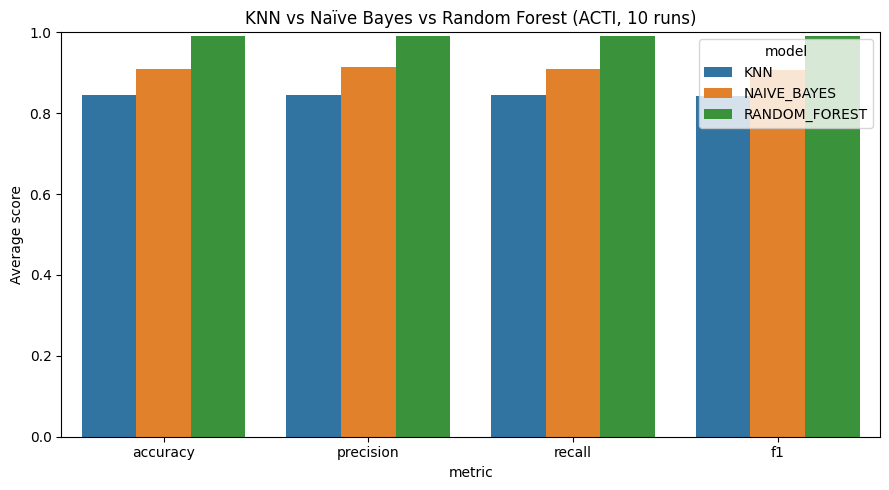

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_reset = avg_metrics.melt(
    id_vars='model',
    var_name='metric',
    value_name='value'
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=metrics_reset,
    x='metric',
    y='value',
    hue='model'
)

plt.title('KNN vs Naïve Bayes vs Random Forest (ACTI, 10 runs)')
plt.ylabel('Average score')
plt.ylim(0, 1)   # use 0–100 if values are percentages
plt.tight_layout()
plt.show()


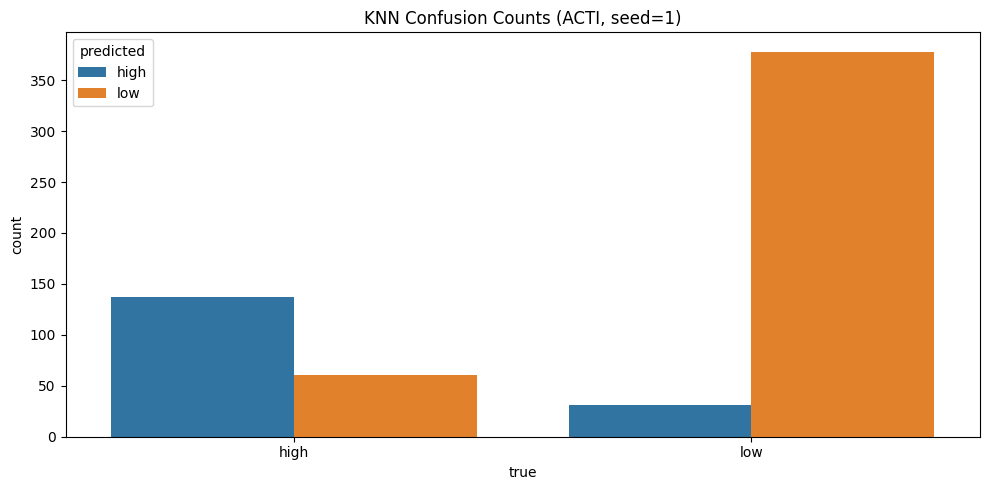

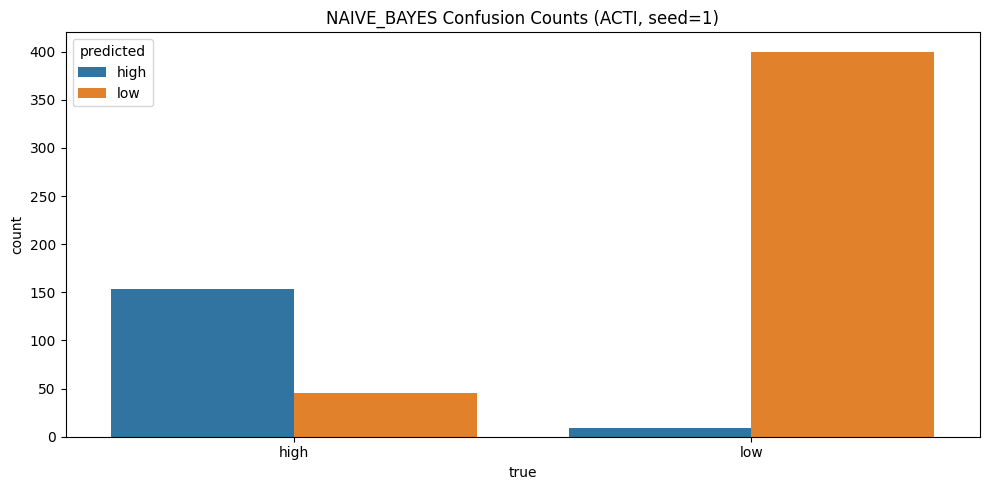

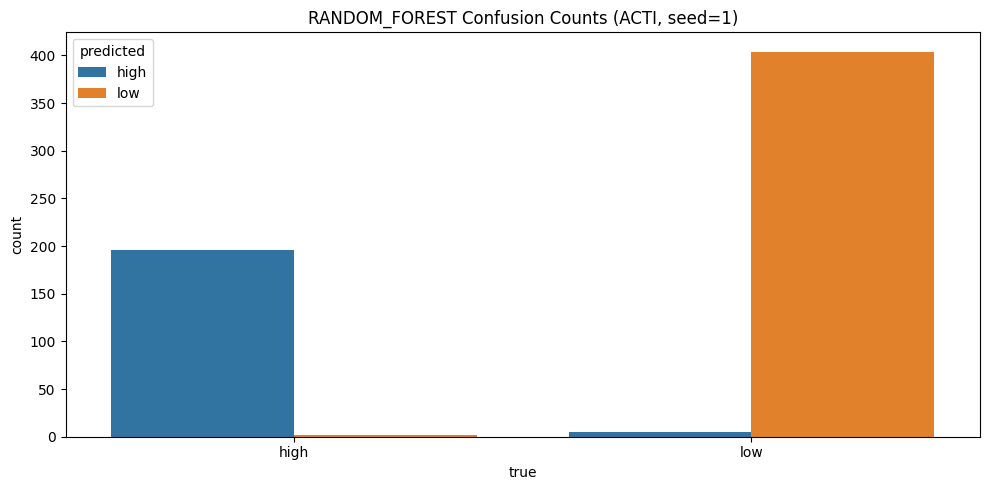

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# One representative run (seed=1) for confusion plots
seed = 1
df_all = pd.concat([df_train, df_dev], ignore_index=True).dropna(subset=["combined_text", "impact_rating"]).copy()

X_text = df_all["combined_text"].astype(str)
y = df_all["impact_rating"].astype(str)

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=seed, stratify=y
)

vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=2, stop_words="english")
X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

models = {
    "knn": KNeighborsClassifier(n_neighbors=5),
    "naive_bayes": MultinomialNB(alpha=1.0),
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=seed, class_weight="balanced"),
}

labels = sorted(y.unique())  # consistent ordering across plots

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)

    cm_melt = cm_df.reset_index().melt(
        id_vars="index", var_name="predicted", value_name="count"
    ).rename(columns={"index": "true"})

    plt.figure(figsize=(10, 5))
    sns.barplot(data=cm_melt, x="true", y="count", hue="predicted")
    plt.title(f"{name.upper()} Confusion Counts (ACTI, seed={seed})")
    plt.tight_layout()
    plt.show()


In [ ]:
# ==== YOUR METRIC VALUES ====

# Random Forest
rf_precision = 0.9775
rf_recall    = 0.9769
rf_f1        = 0.9770
rf_accuracy = 0.9770

# KNN
knn_precision = 0.78   # from classification report (high)
knn_recall    = 0.62
knn_f1        = 0.69
knn_accuracy = 0.8185

# Naive Bayes
nb_precision = 0.94
nb_recall    = 0.72
nb_f1        = 0.81
nb_accuracy = 0.8927


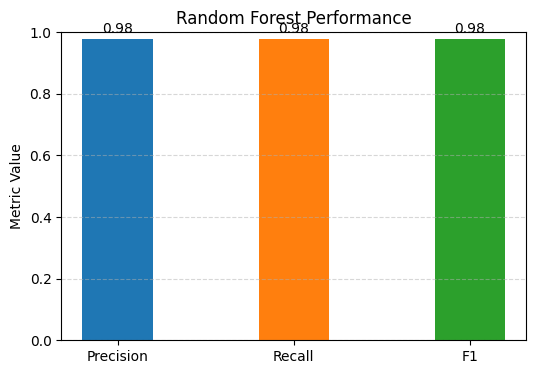

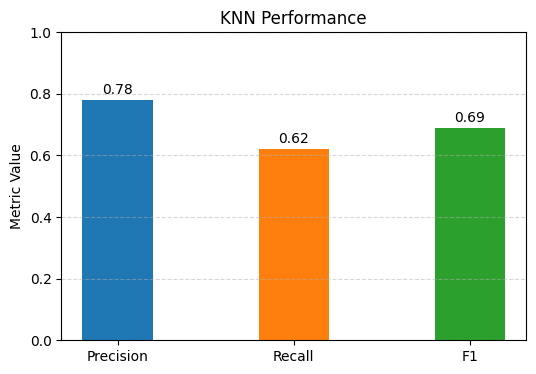

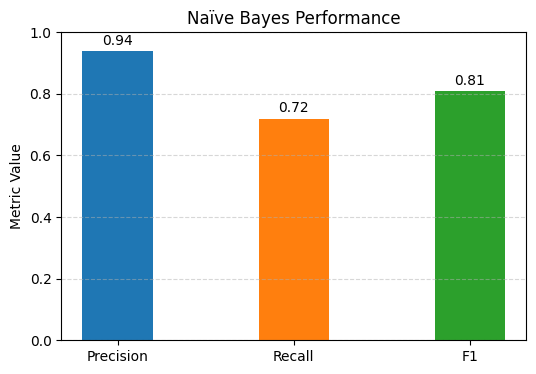

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# RANDOM FOREST GRAPH
# -------------------------------

plt.figure(figsize=(6,4))

bars = plt.bar(["Precision", "Recall", "F1"], [rf_precision, rf_recall, rf_f1], color=["#1f77b4", "#ff7f0e", "#2ca02c"],width = 0.4)
plt.ylim(0, 1)
plt.title("Random Forest Performance")
plt.ylabel("Metric Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center', va='bottom', fontsize=10
    )
plt.show()

# -------------------------------
# KNN GRAPH
# -------------------------------
plt.figure(figsize=(6,4))

bars = plt.bar(["Precision", "Recall", "F1"], [knn_precision, knn_recall, knn_f1], color=["#1f77b4", "#ff7f0e", "#2ca02c"],width = 0.4)
plt.ylim(0, 1)
plt.title("KNN Performance")
plt.ylabel("Metric Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center', va='bottom', fontsize=10
    )
plt.show()

# -------------------------------
# NAIVE BAYES GRAPH
# -------------------------------
plt.figure(figsize=(6,4))

bars = plt.bar(["Precision", "Recall", "F1"], [nb_precision, nb_recall, nb_f1], color=["#1f77b4", "#ff7f0e", "#2ca02c"],width= 0.4)
plt.ylim(0, 1)
plt.title("Naïve Bayes Performance")
plt.ylabel("Metric Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center', va='bottom', fontsize=10
    )
plt.show()


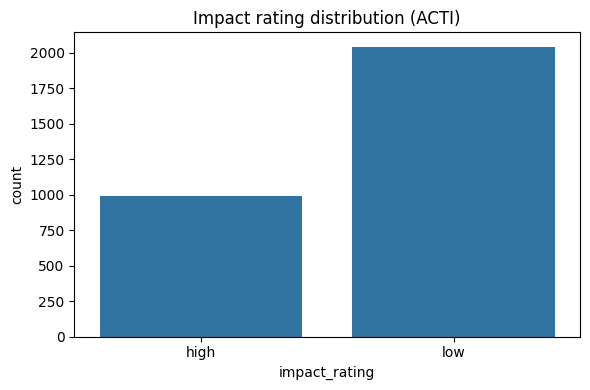

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(
    data=df_all,
    x='impact_rating',
    order=sorted(df_all['impact_rating'].unique())
)
plt.title('Impact rating distribution (ACTI)')
plt.tight_layout()
plt.show()


In [19]:
threats_ml_df = df_all.copy()


In [20]:
threats_ml_df.head()
threats_ml_df.columns


Index(['scenario_id', 'asset', 'attack_type', 'targeted_property',
       'impact_rating', 'combined_text', 'sentence'],
      dtype='object')

In [22]:
import numpy as np

def _build_distance_matrix(risk_values):
    n = len(risk_values)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                dist[i, j] = np.inf
            else:
                dist[i, j] = 1 + abs(risk_values[i] - risk_values[j])
    return dist


def run_aco_on_risk(
    risk_values,
    iterations=20,
    ants=25,
    alpha=1.0,
    beta=2.0,
    rho=0.5,
):
    """
    Lightweight ACO:
    - each scenario = node
    - edge cost = 1 + |risk_i - risk_j|
    """
    risk_values = list(risk_values)
    n = len(risk_values)

    if n < 2:
        return {"best_cost": 0, "best_path": list(range(n)), "history": [0]}

    dist = _build_distance_matrix(risk_values)
    pher = np.ones((n, n))

    best_cost = np.inf
    best_path = None
    history = []

    for _ in range(iterations):
        paths = []
        costs = []

        for _ in range(ants):
            start = np.random.randint(0, n)
            unvisited = set(range(n))
            unvisited.remove(start)
            path = [start]

            while unvisited:
                i = path[-1]
                probs = []
                nodes = []

                for j in unvisited:
                    tau = pher[i, j] ** alpha
                    eta = (1.0 / dist[i, j]) ** beta
                    probs.append(tau * eta)
                    nodes.append(j)

                probs = np.array(probs)
                probs = probs / probs.sum()
                next_node = np.random.choice(nodes, p=probs)
                path.append(next_node)
                unvisited.remove(next_node)

            cost = sum(dist[path[k], path[k + 1]] for k in range(len(path) - 1))
            paths.append(path)
            costs.append(cost)

        pher *= (1 - rho)
        for path, cost in zip(paths, costs):
            for k in range(len(path) - 1):
                i, j = path[k], path[k + 1]
                pher[i, j] += 1.0 / cost

        min_cost = min(costs)
        if min_cost < best_cost:
            best_cost = min_cost
            best_path = paths[costs.index(min_cost)]

        history.append(best_cost)

    return {
        "best_cost": best_cost,
        "best_path": best_path,
        "history": history,
    }


In [26]:
import numpy as np

def run_aco_avg(
    risk_values,
    runs=10,
    iterations=20,
    ants=25,
    sample_size=100,
    seed=21,
):
    """
    Run ACO multiple times on sampled risk values
    and return the average best cost.
    """
    rng = np.random.default_rng(seed)
    costs = []

    for _ in range(runs):
        sample = rng.choice(
            risk_values,
            size=min(sample_size, len(risk_values)),
            replace=False
        ).tolist()

        out = run_aco_on_risk(
            sample,
            iterations=iterations,
            ants=ants
        )
        costs.append(out["best_cost"])

    return float(np.mean(costs)) if costs else 0.0


In [27]:
aco_run_threats = run_aco_on_risk(
    risk_sample_threats,
    iterations=20,
    ants=25
)


In [28]:
df_all
threats_ml_df
risk_sample_threats
run_aco_on_risk


<function __main__.run_aco_on_risk(risk_values, iterations=20, ants=25, alpha=1.0, beta=2.0, rho=0.5)>

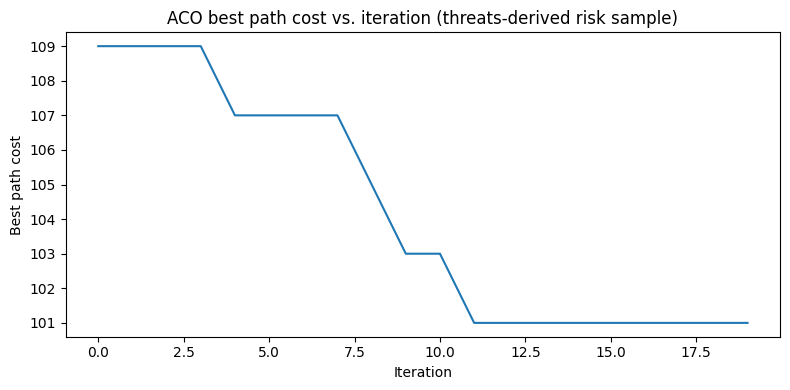

,dataset,iter1_cost,final_cost,avg_best_cost_over_runs
0,Threats-derived sample (proxy risk),109.0,101.0,101.0


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Impact mapping that works for both 5-class and ACTI high/low ---
impact_score_5 = {'inconsequential':1,'minor':2,'moderate':3,'major':4,'severe':5}
impact_score_bin = {'low':2, 'high':4}  # proxy mapping for ACTI-style labels

impact_series = threats_ml_df['impact_rating'].astype(str).str.lower()

impact_num = impact_series.map(impact_score_5)
if impact_num.isna().any():
    # fallback for binary labels
    impact_num = impact_series.map(impact_score_bin)

# if still NaN, fill with median proxy (3)
impact_num = impact_num.fillna(3).astype(float)

# --- Feasibility ---
if 'feasibility_score' in threats_ml_df.columns:
    feas_scores = pd.to_numeric(threats_ml_df['feasibility_score'], errors='coerce').fillna(1).astype(float)
else:
    feas_scores = pd.Series([1.0] * len(threats_ml_df))

# --- Proxy risk (clip to 1..5) ---
risk_threats = (impact_num + feas_scores - 1).clip(1, 5)

risk_sample_threats = risk_threats.sample(
    n=min(100, len(risk_threats)),
    random_state=11
).tolist()

aco_run_threats = run_aco_on_risk(risk_sample_threats, iterations=20, ants=25)

plt.figure(figsize=(8,4))
plt.plot(aco_run_threats['history'])
plt.title('ACO best path cost vs. iteration (threats-derived risk sample)')
plt.xlabel('Iteration')
plt.ylabel('Best path cost')
plt.tight_layout()
plt.show()

aco_avg_cost_threats = run_aco_avg(
    risk_sample_threats,
    runs=10,
    iterations=20,
    ants=25,
    sample_size=min(100, len(risk_sample_threats)),
    seed=21
)

iter1_cost_t = aco_run_threats['history'][0] if aco_run_threats['history'] else None
final_cost_t = aco_run_threats['history'][-1] if aco_run_threats['history'] else None

aco_summary_threats = pd.DataFrame([{
    'dataset': 'Threats-derived sample (proxy risk)',
    'iter1_cost': iter1_cost_t,
    'final_cost': final_cost_t,
    'avg_best_cost_over_runs': aco_avg_cost_threats,
}])

aco_summary_threats
